# Chapter 8: Hermitian Symmetric Spaces

**Source Span.** Helgason, Chapter VIII, printed pages 352-400 (source map), checked against the PDF extraction at approximately PDF pages 379-427.

**Chapter Goal.** Build a working model of Hermitian symmetric spaces as the meeting point of complex geometry, symmetric-space curvature, and bounded domains. By the end, the reader should be able to inspect an almost complex structure, recognize the Kahler/Ricci constraints used in the chapter, see why the Bergman metric makes bounded symmetric domains into Hermitian symmetric spaces, and track the Cartan-Harish-Chandra realization `G0/K0 -> D subset p_-`.

The notebook is deliberately not a replacement scan of the book. It is a computational companion: every picture below is generated from small formulas or finite diagrams, and every generated file is written under the Chapter 8 artifact directory.


## Source Span And Visual Storyboard

**Chapter implementation brief.**

**Concept inventory.** The source span starts with almost complex manifolds and the torsion tensor `S`, then passes to complexified tangent fields, `(1,0)` and `(0,1)` types, Hermitian and Kahler metrics, Ricci curvature, Bergman kernels, Hermitian symmetric spaces, compact/noncompact type, irreducible orthogonal symmetric Lie algebras, the isotropy-center criterion, and finally the bounded-domain realization by the Cartan-Harish-Chandra map.

**Teaching route.** The chapter is proof-heavy, so the visual sequence uses a dependency graph, block-structure diagrams, symbolic identity checks, and rank-one/rank-two bounded-domain models rather than decorative surfaces. The rank-one disk stands in for the `SL(2,C)` example near the end of the chapter; the rank-two tanh square displays the strongly orthogonal coordinate behavior in Corollaries 7.17-7.18.

**Visual sequence.**

1. `ch08-source-dependency-graph.png`: source-section proof dependencies from almost complex data to bounded symmetric domains.
2. `almost-complex-type-splitting.png`: `J^2=-I`, type projections, and the integrability checkpoint.
3. `kahler-ricci-block-structure.png`: the Hermitian/Kahler zero-block pattern for complex tensors and curvature.
4. `bergman-disk-ricci-profile.png`: the disk Bergman metric and the Ricci identity `Ric = -g` in complex dimension one.
5. `bergman-disk-symmetry.png`: a holomorphic involution of the disk, with metric preservation checked numerically.
6. `isotropy-center-complex-structure.png`: the center circle in the isotropy group generating the complex structure.
7. `harish-chandra-factorization.png` and `harish-chandra-tanh-domain.html`: the factorization diagram and bounded tanh coordinates.

**Proof-visualization strategy.** The graph shows which earlier ingredients feed Theorem 7.1. The disk and tanh models turn the key proof moves into checks: holomorphic symmetries preserve the Bergman metric; the noncompact geodesic coordinate `t` is bounded by `tanh(t)`; and boundary limits land at cube vertices.

**Acceptance criteria.** The notebook must execute with `nbclient`, display generated artifacts with `display_artifact(...)`, save JSON/CSV invariant summaries, and finish by writing `checks/final_sanity.json`.


In [1]:
from __future__ import annotations

from pathlib import Path
import json
import math
import sys

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle, FancyArrowPatch
import networkx as nx
import plotly.graph_objects as go

COURSE_ROOT = next(
    candidate for candidate in [Path.cwd(), *Path.cwd().parents]
    if (candidate / "AGENTS.md").exists() and (candidate / "source_map.json").exists() and (candidate / "utils").exists()
)
if str(COURSE_ROOT) not in sys.path:
    sys.path.insert(0, str(COURSE_ROOT))

from utils.artifacts import (
    assert_artifacts,
    chapter_artifact_root,
    display_artifact,
    find_book_root,
    save_csv,
    save_json,
    save_matplotlib,
)

BOOK_ROOT = find_book_root()
UNIT_KEY = "chapter-08-hermitian-symmetric-spaces"
UNIT_TITLE = "Hermitian Symmetric Spaces"
ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIG = ARTIFACT_ROOT / "figures"
HTML = ARTIFACT_ROOT / "html"
CHECKS = ARTIFACT_ROOT / "checks"
TABLES = ARTIFACT_ROOT / "tables"

PALETTE = {
    "ink": "#202124",
    "muted": "#5f6368",
    "blue": "#2f6fbb",
    "green": "#228b64",
    "gold": "#c98918",
    "red": "#b84545",
    "violet": "#7b61a8",
    "teal": "#0e7c86",
    "paper": "#fbfbf8",
}

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#333333",
    "axes.labelcolor": "#202124",
    "xtick.color": "#202124",
    "ytick.color": "#202124",
    "font.size": 11,
})

def artifact(*parts: str) -> Path:
    return ARTIFACT_ROOT.joinpath(*parts)


## Library Routing

| Chapter concept | Representation | Library | Why this route | Fallback |
| --- | --- | --- | --- | --- |
| Almost complex structure and type splitting | Matrix/projection diagram plus exact identities | SymPy, Matplotlib | `J^2=-I` and type projections are algebraic, while the diagram shows the two real directions becoming one complex direction. | Hand-drawn static Matplotlib diagram only |
| Hermitian/Kahler tensor restrictions | Block matrix diagram and symbolic skew-form check | SymPy, Matplotlib | The chapter repeatedly uses zero blocks such as `g_{ij}=0` and same-type curvature vanishing. | Markdown table |
| Ricci curvature and Bergman metric | Exact disk computation and metric heatmap | SymPy, NumPy, Matplotlib | The unit disk is the smallest bounded symmetric domain and exposes the chapter's Ricci/Kahler mechanism. | Numeric finite differences |
| Holomorphic disk symmetry | Involution plot and metric-preservation residuals | NumPy, Matplotlib | The definition of bounded symmetric domain asks for involutive holomorphic symmetries with isolated fixed points. | Algebra-only check |
| Isotropy center and complex structure | Circle action on tangent vectors | SymPy, Matplotlib | Theorem 4.5 and Proposition 6.2 identify Hermitian type through a central circle in the isotropy group. | Textual Lie-algebra summary |
| Cartan-Harish-Chandra realization | Factorization diagram and interactive bounded tanh coordinates | NetworkX, Matplotlib, Plotly | The proof constructs `G0/K0` as a bounded domain in `p_-`; Plotly lets the learner inspect tanh limits. | Static tanh-square plot |


In [2]:
routing_rows = [
    {
        "concept": "almost complex type splitting",
        "representation": "matrix projection diagram",
        "library": "SymPy + Matplotlib",
        "inspection_target": "J^2=-I and complementary (1,0)/(0,1) projections",
        "artifact": "figures/almost-complex-type-splitting.png",
    },
    {
        "concept": "Kahler and Ricci tensor restrictions",
        "representation": "block matrix and exact disk Ricci check",
        "library": "SymPy + Matplotlib",
        "inspection_target": "zero same-type metric blocks and Ricci = -g on the disk model",
        "artifact": "figures/kahler-ricci-block-structure.png",
    },
    {
        "concept": "Bergman metric symmetry",
        "representation": "disk involution with residuals",
        "library": "NumPy + Matplotlib",
        "inspection_target": "holomorphic involution fixes one point and preserves metric density",
        "artifact": "figures/bergman-disk-symmetry.png",
    },
    {
        "concept": "isotropy center",
        "representation": "center-circle phase action",
        "library": "SymPy + Matplotlib",
        "inspection_target": "central S1 action commutes with J and preserves the tangent metric",
        "artifact": "figures/isotropy-center-complex-structure.png",
    },
    {
        "concept": "Cartan-Harish-Chandra bounded realization",
        "representation": "factorization diagram and tanh-coordinate explorer",
        "library": "NetworkX + Plotly",
        "inspection_target": "p_- coordinates stay bounded and geodesic limits approach cube vertices",
        "artifact": "html/harish-chandra-tanh-domain.html",
    },
]
routing_path = save_csv(routing_rows, artifact("tables", "ch08-library-routing.csv"))
display_artifact(routing_path)


[ch08-library-routing.csv](artifacts/chapter-08-hermitian-symmetric-spaces/tables/ch08-library-routing.csv)

## Chapter Dependency Graph

Read this graph left to right. The first three sections supply the complex-analytic and curvature tools. Sections 4-6 identify which symmetric spaces are Hermitian through the isotropy representation and its center. Section 7 uses that structure to build the bounded domain `D subset p_-` and the compact-dual embedding.


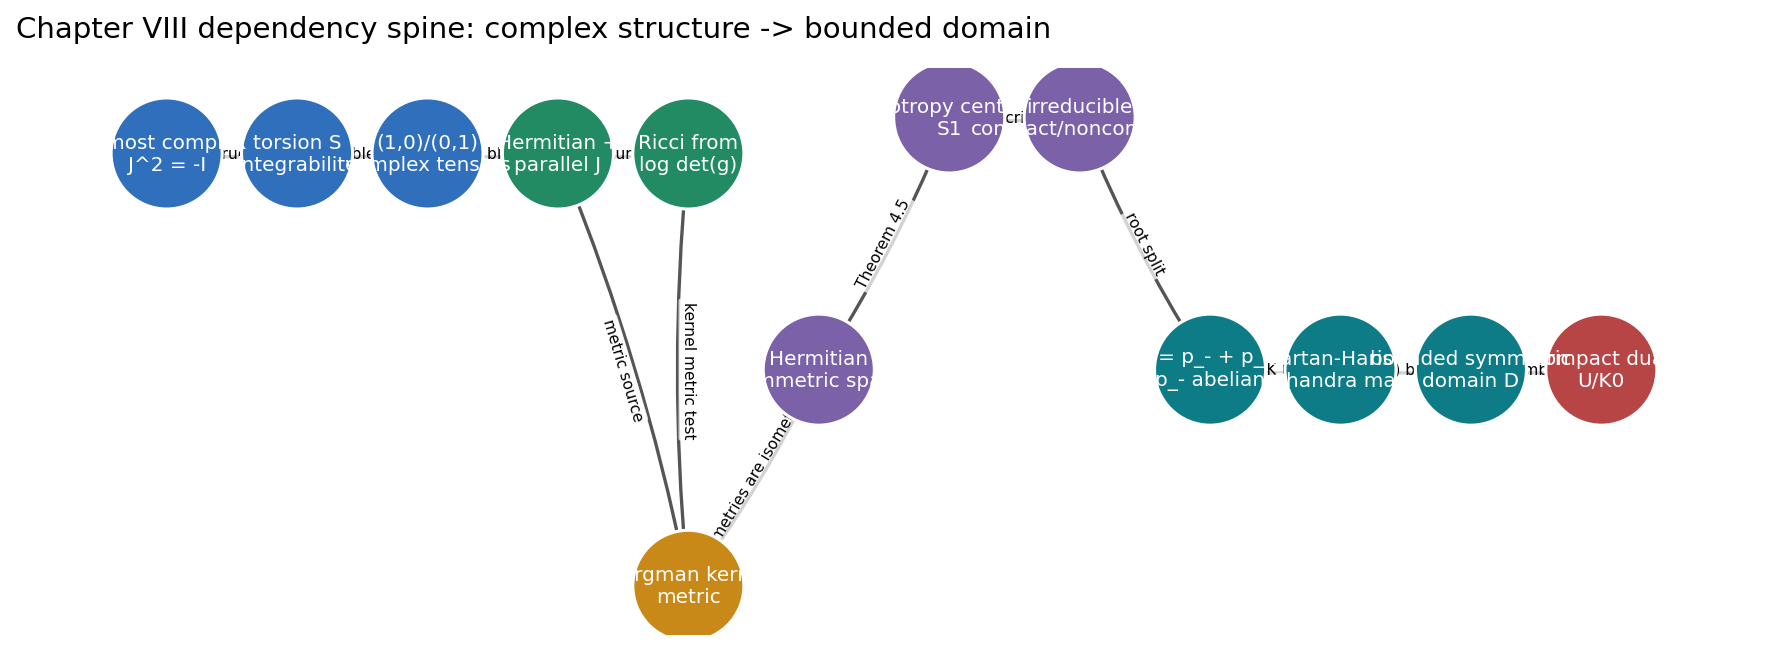

`ch08-storyboard.json`

In [3]:
nodes = {
    "almost": "Almost complex\nJ^2 = -I",
    "torsion": "torsion S\nintegrability",
    "types": "(1,0)/(0,1)\ncomplex tensors",
    "kahler": "Hermitian +\nparallel J",
    "ricci": "Ricci from\nlog det(g)",
    "bergman": "Bergman kernel\nmetric",
    "hss": "Hermitian\nsymmetric space",
    "center": "isotropy center\nS1",
    "irreducible": "irreducible\ncompact/noncompact",
    "pminus": "p = p_- + p_+\np_- abelian",
    "chc": "Cartan-Harish-\nChandra map",
    "bounded": "bounded symmetric\ndomain D",
    "compactdual": "compact dual\nU/K0",
}
edges = [
    ("almost", "torsion", "obstruction"),
    ("torsion", "types", "integrable charts"),
    ("types", "kahler", "zero blocks"),
    ("kahler", "ricci", "curvature type"),
    ("bergman", "kahler", "metric source"),
    ("bergman", "hss", "symmetries are isometries"),
    ("hss", "center", "Theorem 4.5"),
    ("center", "irreducible", "circle criterion"),
    ("irreducible", "pminus", "root split"),
    ("pminus", "chc", "P_- K P_+"),
    ("chc", "bounded", "log xi(x) bounded"),
    ("bounded", "compactdual", "open embedding"),
    ("ricci", "bergman", "kernel metric test"),
]
G = nx.DiGraph()
for key, label in nodes.items():
    G.add_node(key, label=label)
for u, v, label in edges:
    G.add_edge(u, v, label=label)

pos = {
    "almost": (0, 2),
    "torsion": (1.2, 2),
    "types": (2.4, 2),
    "kahler": (3.6, 2),
    "ricci": (4.8, 2),
    "bergman": (4.8, 0.8),
    "hss": (6.0, 1.4),
    "center": (7.2, 2.1),
    "irreducible": (8.4, 2.1),
    "pminus": (9.6, 1.4),
    "chc": (10.8, 1.4),
    "bounded": (12.0, 1.4),
    "compactdual": (13.2, 1.4),
}
fig, ax = plt.subplots(figsize=(14, 4.6))
ax.set_facecolor(PALETTE["paper"])
node_colors = [
    PALETTE["blue"], PALETTE["blue"], PALETTE["blue"], PALETTE["green"], PALETTE["green"],
    PALETTE["gold"], PALETTE["violet"], PALETTE["violet"], PALETTE["violet"],
    PALETTE["teal"], PALETTE["teal"], PALETTE["teal"], PALETTE["red"]
]
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=2500, edgecolors="#ffffff", linewidths=1.4, ax=ax)
nx.draw_networkx_labels(G, pos, labels=nx.get_node_attributes(G, "label"), font_color="white", font_size=9, ax=ax)
nx.draw_networkx_edges(G, pos, arrows=True, arrowstyle="-|>", arrowsize=18, width=1.5, edge_color="#555555", ax=ax, connectionstyle="arc3,rad=0.05")
edge_labels = nx.get_edge_attributes(G, "label")
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7, bbox={"boxstyle": "round,pad=0.15", "fc": "white", "ec": "none", "alpha": 0.75}, ax=ax)
ax.set_title("Chapter VIII dependency spine: complex structure -> bounded domain", loc="left", pad=14)
ax.set_axis_off()
dependency_path = save_matplotlib(fig, artifact("figures", "ch08-source-dependency-graph.png"))
plt.close(fig)

storyboard = {
    "chapter_goal": "Connect complex structures, Kahler/Ricci geometry, Bergman metrics, isotropy centers, and the Cartan-Harish-Chandra bounded-domain realization.",
    "source_span_read": "Printed pages 352-400, approximate PDF pages 379-427.",
    "concept_inventory": list(nodes.values()),
    "visual_sequence": [row["artifact"] for row in routing_rows] + ["figures/ch08-source-dependency-graph.png"],
    "proof_visualization_strategy": "Dependency graph plus exact/sampled invariants for the disk, isotropy center, and tanh bounded coordinates.",
}
storyboard_path = save_json(storyboard, artifact("checks", "ch08-storyboard.json"))

display_artifact(dependency_path, width=900)
display_artifact(storyboard_path)


## Almost Complex Structures And Type Splitting

An almost complex structure is a smoothly varying operator `J` with `J^2=-I`. The source then introduces a torsion tensor `S`; when `S=0`, the almost complex data comes from genuine complex coordinate charts. Computationally, the first inspection is algebraic: `J` should have eigenvalues `+i` and `-i` after complexification, giving the type decomposition.

The standard plane model is small but faithful to the local formulas: `J(dx direction) = dy direction`, `J(dy direction) = -dx direction`, the coordinate brackets vanish, and the projections onto `(1,0)` and `(0,1)` types are complementary idempotents.


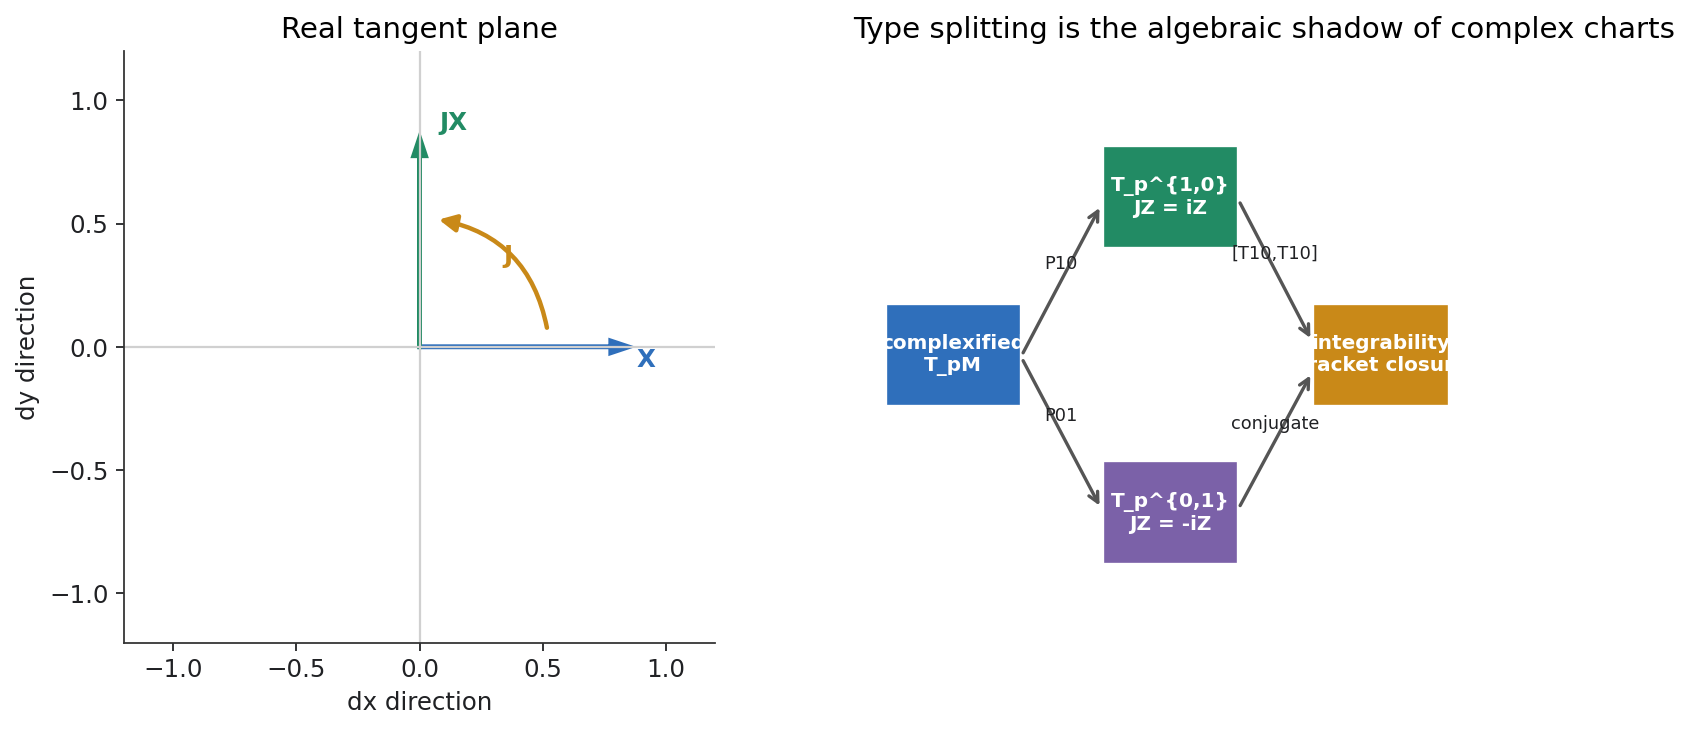

`almost-complex-type-splitting.json`

In [4]:
I2 = sp.eye(2)
J = sp.Matrix([[0, -1], [1, 0]])
i = sp.I
P10 = sp.Rational(1, 2) * (I2 - i * J)
P01 = sp.Rational(1, 2) * (I2 + i * J)

checks_almost = {
    "J_squared_is_minus_I": sp.simplify(J * J + I2) == sp.zeros(2),
    "P10_idempotent": sp.simplify(P10 * P10 - P10) == sp.zeros(2),
    "P01_idempotent": sp.simplify(P01 * P01 - P01) == sp.zeros(2),
    "P10_plus_P01_is_identity": sp.simplify(P10 + P01 - I2) == sp.zeros(2),
    "P10_P01_is_zero": sp.simplify(P10 * P01) == sp.zeros(2),
    "coordinate_torsion_standard_chart": [0, 0],
}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
ax = axes[0]
ax.set_aspect("equal")
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.axhline(0, color="#d0d0d0", lw=1)
ax.axvline(0, color="#d0d0d0", lw=1)
ax.arrow(0, 0, 0.85, 0, head_width=0.05, length_includes_head=True, color=PALETTE["blue"], lw=2)
ax.arrow(0, 0, 0, 0.85, head_width=0.05, length_includes_head=True, color=PALETTE["green"], lw=2)
ax.text(0.88, -0.08, "X", color=PALETTE["blue"], weight="bold")
ax.text(0.08, 0.88, "JX", color=PALETTE["green"], weight="bold")
ax.add_patch(FancyArrowPatch((0.52, 0.06), (0.06, 0.52), connectionstyle="arc3,rad=0.35", arrowstyle="-|>", mutation_scale=16, color=PALETTE["gold"], lw=2))
ax.text(0.34, 0.34, "J", color=PALETTE["gold"], weight="bold")
ax.set_title("Real tangent plane")
ax.set_xlabel("dx direction")
ax.set_ylabel("dy direction")

ax = axes[1]
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.axis("off")
boxes = [
    (0.5, 2.4, "complexified\nT_pM", PALETTE["blue"]),
    (4.0, 4.0, "T_p^{1,0}\nJZ = iZ", PALETTE["green"]),
    (4.0, 0.8, "T_p^{0,1}\nJZ = -iZ", PALETTE["violet"]),
    (7.4, 2.4, "integrability\nbracket closure", PALETTE["gold"]),
]
for x0, y0, label, color in boxes:
    rect = Rectangle((x0, y0), 2.2, 1.05, facecolor=color, edgecolor="white", lw=1.5)
    ax.add_patch(rect)
    ax.text(x0 + 1.1, y0 + 0.52, label, ha="center", va="center", color="white", weight="bold", fontsize=9)
for start, end, text in [
    ((2.7, 2.9), (4.0, 4.45), "P10"),
    ((2.7, 2.9), (4.0, 1.35), "P01"),
    ((6.2, 4.5), (7.4, 3.05), "[T10,T10]"),
    ((6.2, 1.35), (7.4, 2.75), "conjugate"),
]:
    ax.annotate("", xy=end, xytext=start, arrowprops={"arrowstyle": "->", "color": "#555555", "lw": 1.5})
    mx, my = (start[0] + end[0]) / 2, (start[1] + end[1]) / 2
    ax.text(mx, my + 0.12, text, ha="center", fontsize=8, color=PALETTE["ink"])
ax.set_title("Type splitting is the algebraic shadow of complex charts", loc="left")

almost_path = save_matplotlib(fig, artifact("figures", "almost-complex-type-splitting.png"))
plt.close(fig)
almost_check_path = save_json({k: (bool(v) if not isinstance(v, list) else v) for k, v in checks_almost.items()}, artifact("checks", "almost-complex-type-splitting.json"))

display_artifact(almost_path, width=820)
display_artifact(almost_check_path)


## Hermitian, Kahler, And Ricci Blocks

The chapter's tensor calculations become easier once the reader can see the block pattern. A Hermitian metric pairs `(1,0)` vectors with `(0,1)` vectors; same-type pairings vanish. A Kahler metric adds parallelism of `J`, which forces same-type curvature components to vanish. That is the local tensor language behind the later symmetric-space statements.

The Ricci curvature then appears as a trace of curvature. In Kahler coordinates it can be read from the determinant of the Hermitian metric matrix; the next disk computation makes this exact.


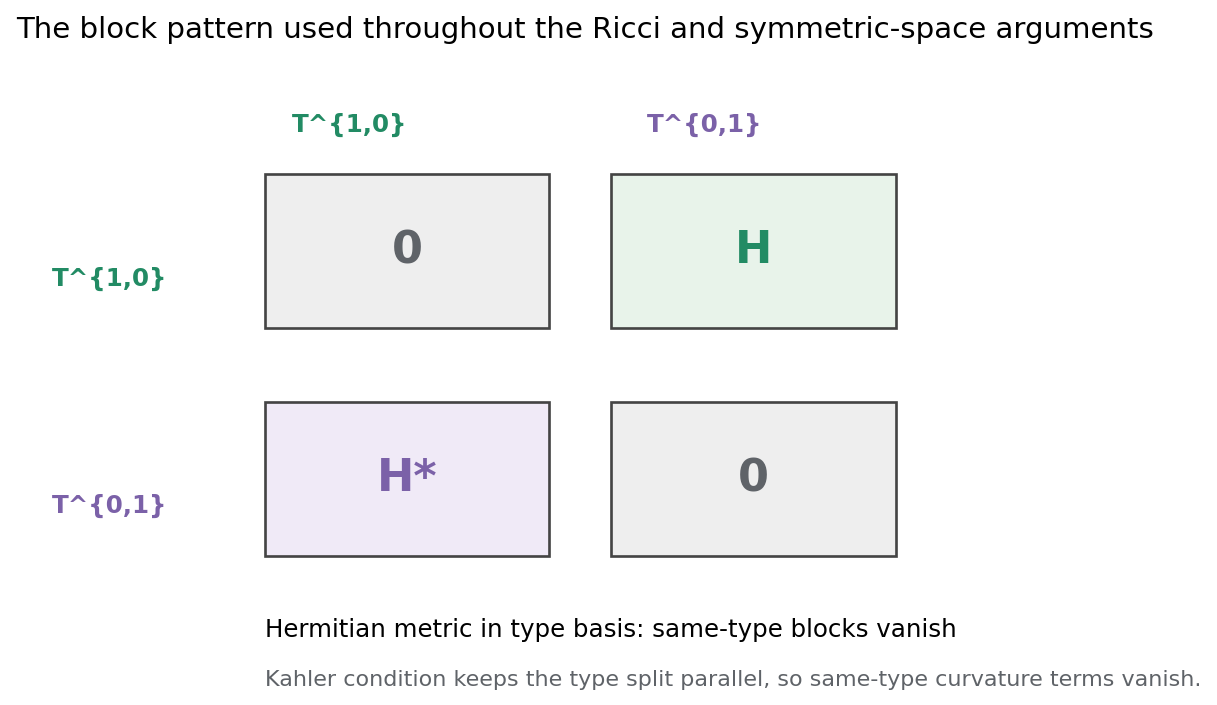

`kahler-ricci-block-structure.json`

In [5]:
J4 = sp.Matrix([[0, -1, 0, 0], [1, 0, 0, 0], [0, 0, 0, -1], [0, 0, 1, 0]])
G4 = sp.eye(4)
omega = G4 * J4
H = sp.Matrix([[2, 1 + sp.I], [1 - sp.I, 3]])
H_eigs = [sp.N(ev) for ev in H.eigenvals().keys()]

kahler_checks = {
    "omega_is_skew": sp.simplify(omega + omega.T) == sp.zeros(4),
    "J_is_metric_orthogonal": sp.simplify(J4.T * G4 * J4 - G4) == sp.zeros(4),
    "sample_hermitian_matrix_positive": all(float(sp.re(ev)) > 0 for ev in H_eigs),
    "same_type_metric_blocks": "g_ij = g_bar_i_bar_j = 0",
    "same_type_kahler_curvature": "R_ij = R_bar_i_bar_j = 0",
}

fig, ax = plt.subplots(figsize=(8.6, 5.0))
ax.set_xlim(0, 6)
ax.set_ylim(0, 5)
ax.axis("off")
labels = [
    (0.2, 3.1, "T^{1,0}", PALETTE["green"]),
    (0.2, 1.25, "T^{0,1}", PALETTE["violet"]),
    (1.55, 4.35, "T^{1,0}", PALETTE["green"]),
    (3.55, 4.35, "T^{0,1}", PALETTE["violet"]),
]
for x0, y0, label, color in labels:
    ax.text(x0, y0, label, color=color, weight="bold")
blocks = [
    (1.4, 2.75, "0", "#eeeeee", PALETTE["muted"]),
    (3.35, 2.75, "H", "#e8f3ea", PALETTE["green"]),
    (1.4, 0.9, "H*", "#f0eaf7", PALETTE["violet"]),
    (3.35, 0.9, "0", "#eeeeee", PALETTE["muted"]),
]
for x0, y0, label, fill, text_color in blocks:
    rect = Rectangle((x0, y0), 1.6, 1.25, facecolor=fill, edgecolor="#444444", lw=1.2)
    ax.add_patch(rect)
    ax.text(x0 + 0.8, y0 + 0.63, label, ha="center", va="center", fontsize=20, color=text_color, weight="bold")
ax.text(1.4, 0.25, "Hermitian metric in type basis: same-type blocks vanish", fontsize=11)
ax.text(1.4, -0.15, "Kahler condition keeps the type split parallel, so same-type curvature terms vanish.", fontsize=10, color=PALETTE["muted"])
ax.set_title("The block pattern used throughout the Ricci and symmetric-space arguments", loc="left")

block_path = save_matplotlib(fig, artifact("figures", "kahler-ricci-block-structure.png"))
plt.close(fig)
block_check_path = save_json({k: (bool(v) if isinstance(v, (bool, np.bool_)) else v) for k, v in kahler_checks.items()}, artifact("checks", "kahler-ricci-block-structure.json"))

display_artifact(block_path, width=760)
display_artifact(block_check_path)


## Disk Bergman Metric And Ricci Curvature

The source defines the Bergman kernel for bounded domains and then takes second derivatives of `log K` to get a Kahler metric. The unit disk is the cleanest laboratory. Up to a harmless positive constant,

`K(z,z) = (1 - |z|^2)^(-2)`.

For `z = x + iy`, `partial_z partial_bar_z = (1/4) Delta`, so the metric coefficient is `g = partial_z partial_bar_z log K`. The Ricci coefficient in complex dimension one is `- partial_z partial_bar_z log g`. The exact symbolic check below gives `Ric = -g` for this normalization.


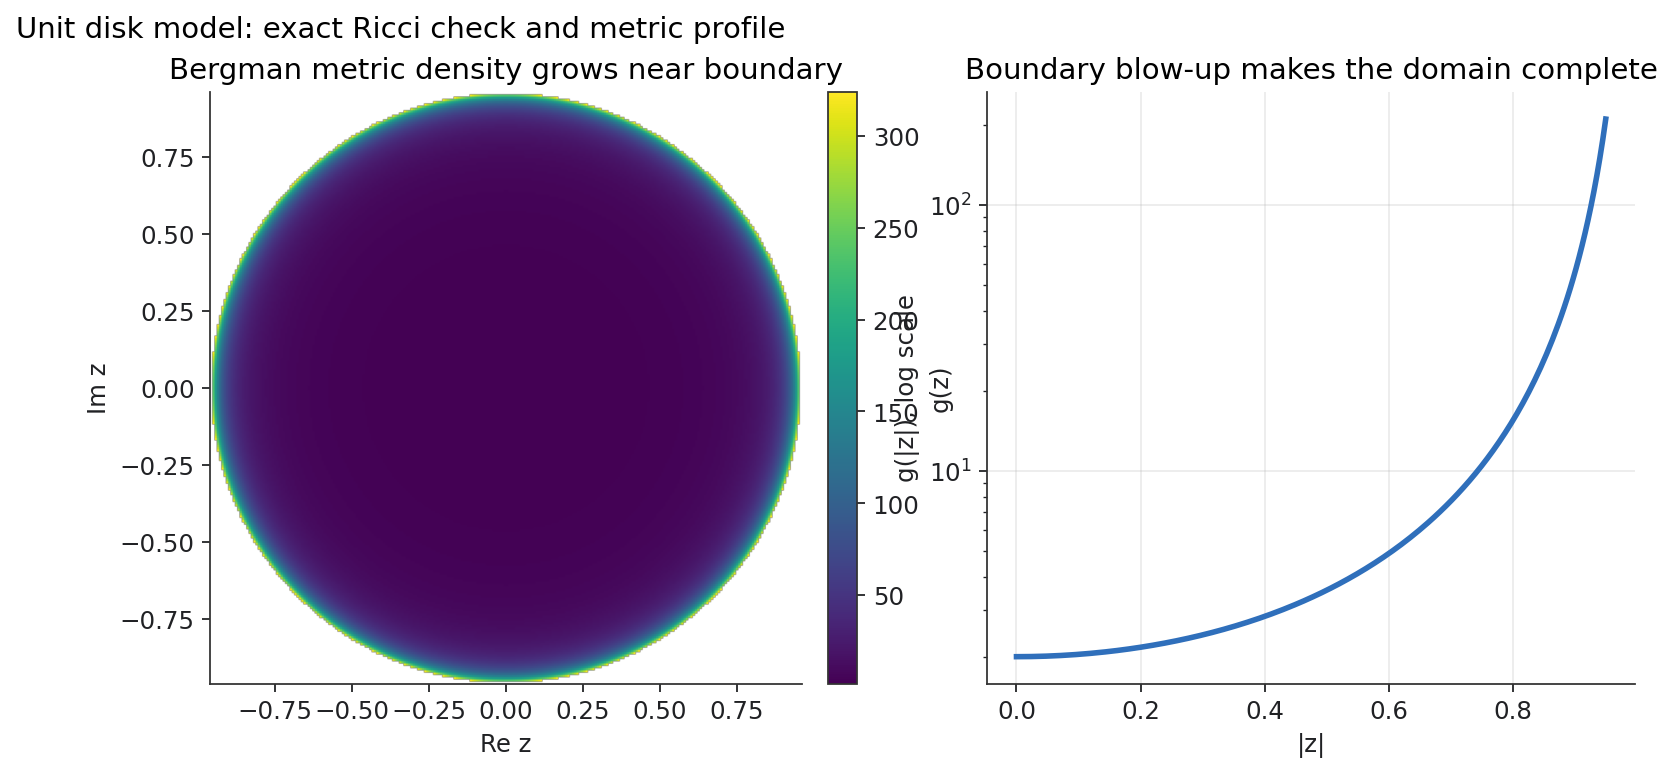

`bergman-disk-ricci-profile.json`

In [6]:
x, y = sp.symbols("x y", real=True)
r2 = x**2 + y**2
logK = -2 * sp.log(1 - r2)
g_disk = sp.simplify(sp.Rational(1, 4) * (sp.diff(logK, x, 2) + sp.diff(logK, y, 2)))
ric_disk = sp.simplify(-sp.Rational(1, 4) * (sp.diff(sp.log(g_disk), x, 2) + sp.diff(sp.log(g_disk), y, 2)))
ratio = sp.simplify(ric_disk / g_disk)

grid = np.linspace(-0.96, 0.96, 260)
X, Y = np.meshgrid(grid, grid)
R2 = X**2 + Y**2
metric_density = 2 / (1 - R2)**2
metric_density = np.where(R2 < 0.96**2, metric_density, np.nan)
rs = np.linspace(0, 0.95, 200)
radial_density = 2 / (1 - rs**2)**2

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8))
im = axes[0].imshow(metric_density, extent=[grid.min(), grid.max(), grid.min(), grid.max()], origin="lower", cmap="viridis")
axes[0].add_patch(Circle((0, 0), 1, fill=False, color="white", lw=1.4))
axes[0].set_aspect("equal")
axes[0].set_title("Bergman metric density grows near boundary")
axes[0].set_xlabel("Re z")
axes[0].set_ylabel("Im z")
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04, label="g(z)")
axes[1].plot(rs, radial_density, color=PALETTE["blue"], lw=2.5)
axes[1].set_yscale("log")
axes[1].set_xlabel("|z|")
axes[1].set_ylabel("g(|z|), log scale")
axes[1].set_title("Boundary blow-up makes the domain complete")
axes[1].grid(True, alpha=0.25)
fig.suptitle("Unit disk model: exact Ricci check and metric profile", x=0.02, ha="left")

ricci_path = save_matplotlib(fig, artifact("figures", "bergman-disk-ricci-profile.png"))
plt.close(fig)
ricci_check = {
    "log_kernel": "-2*log(1 - x^2 - y^2)",
    "g_z_zbar": str(g_disk),
    "ricci_z_zbar": str(ric_disk),
    "ricci_over_metric": str(ratio),
    "sample_ratio_values": [float(ratio.subs({x: a, y: b})) for a, b in [(0, 0), (0.2, 0.1), (0.5, 0.0)]],
}
ricci_check_path = save_json(ricci_check, artifact("checks", "bergman-disk-ricci-profile.json"))

display_artifact(ricci_path, width=840)
display_artifact(ricci_check_path)


## Bounded Symmetric Domain Test: A Disk Involution

A bounded symmetric domain has an involutive holomorphic symmetry at each point. For the disk, the symmetry fixing `a` is a fractional linear map. This gives a concrete version of the chapter's abstract definition: the symmetry is holomorphic, has an isolated fixed point, squares to the identity, and preserves the Bergman metric.

The plot sends a small grid of sample points through one such symmetry. The JSON residuals check the two important invariants: `s_a(s_a(z)) = z` and metric density preservation.


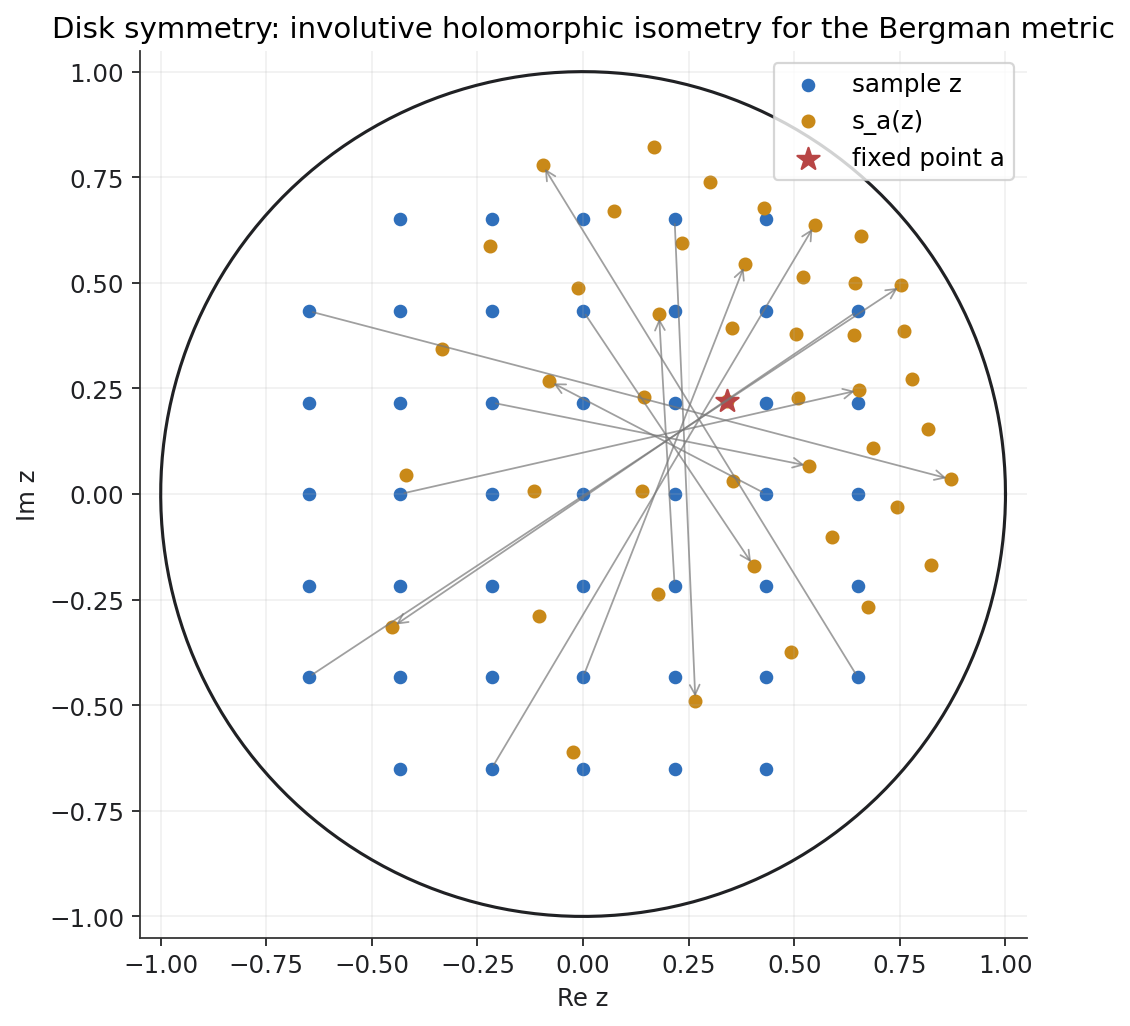

`bergman-disk-symmetry.json`

In [7]:
def disk_symmetry(a: complex, z: np.ndarray | complex) -> np.ndarray | complex:
    return (a - z) / (1 - np.conjugate(a) * z)

def disk_symmetry_derivative(a: complex, z: np.ndarray | complex) -> np.ndarray | complex:
    return (abs(a) ** 2 - 1) / (1 - np.conjugate(a) * z) ** 2

def bergman_density(z: np.ndarray | complex) -> np.ndarray | float:
    return 2 / (1 - np.abs(z) ** 2) ** 2

a = 0.34 + 0.22j
xs = np.linspace(-0.65, 0.65, 7)
ys = np.linspace(-0.65, 0.65, 7)
pts = np.array([xx + 1j * yy for xx in xs for yy in ys if abs(xx + 1j * yy) < 0.82])
imgs = disk_symmetry(a, pts)

involution_error = float(np.max(np.abs(disk_symmetry(a, imgs) - pts)))
fixed_error = float(abs(disk_symmetry(a, a) - a))
metric_residuals = bergman_density(imgs) * np.abs(disk_symmetry_derivative(a, pts)) ** 2 / bergman_density(pts) - 1
max_metric_residual = float(np.max(np.abs(metric_residuals)))

theta = np.linspace(0, 2 * np.pi, 400)
circle = np.exp(1j * theta)

fig, ax = plt.subplots(figsize=(7.2, 7.2))
ax.plot(circle.real, circle.imag, color=PALETTE["ink"], lw=1.4)
ax.scatter(pts.real, pts.imag, s=26, color=PALETTE["blue"], label="sample z")
ax.scatter(imgs.real, imgs.imag, s=28, color=PALETTE["gold"], label="s_a(z)")
for z0, z1 in zip(pts[::4], imgs[::4]):
    ax.annotate("", xy=(z1.real, z1.imag), xytext=(z0.real, z0.imag), arrowprops={"arrowstyle": "->", "color": "#777777", "lw": 0.8, "alpha": 0.7})
ax.scatter([a.real], [a.imag], s=110, marker="*", color=PALETTE["red"], label="fixed point a")
ax.set_aspect("equal")
ax.set_xlim(-1.05, 1.05)
ax.set_ylim(-1.05, 1.05)
ax.set_xlabel("Re z")
ax.set_ylabel("Im z")
ax.set_title("Disk symmetry: involutive holomorphic isometry for the Bergman metric")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.18)

symmetry_path = save_matplotlib(fig, artifact("figures", "bergman-disk-symmetry.png"))
plt.close(fig)
symmetry_check = {
    "fixed_point": [a.real, a.imag],
    "max_involution_error": involution_error,
    "fixed_point_error": fixed_error,
    "max_metric_density_residual": max_metric_residual,
    "sample_count": int(len(pts)),
}
symmetry_check_path = save_json(symmetry_check, artifact("checks", "bergman-disk-symmetry.json"))

display_artifact(symmetry_path, width=680)
display_artifact(symmetry_check_path)


## Hermitian Symmetric Spaces: The Isotropy-Center Test

For compact and noncompact irreducible Hermitian symmetric spaces, the isotropy group is not semisimple: its center contains a circle. This is the structural fingerprint that distinguishes Hermitian symmetric spaces among symmetric spaces. Infinitesimally, a central element `H0` acts on the tangent space by `J0 = ad(H0)`, and that action commutes with the isotropy representation.

The finite-dimensional model below shows the local picture. A central circle rotates each complex tangent line by phase, preserves the metric, and has derivative `J` at the identity.


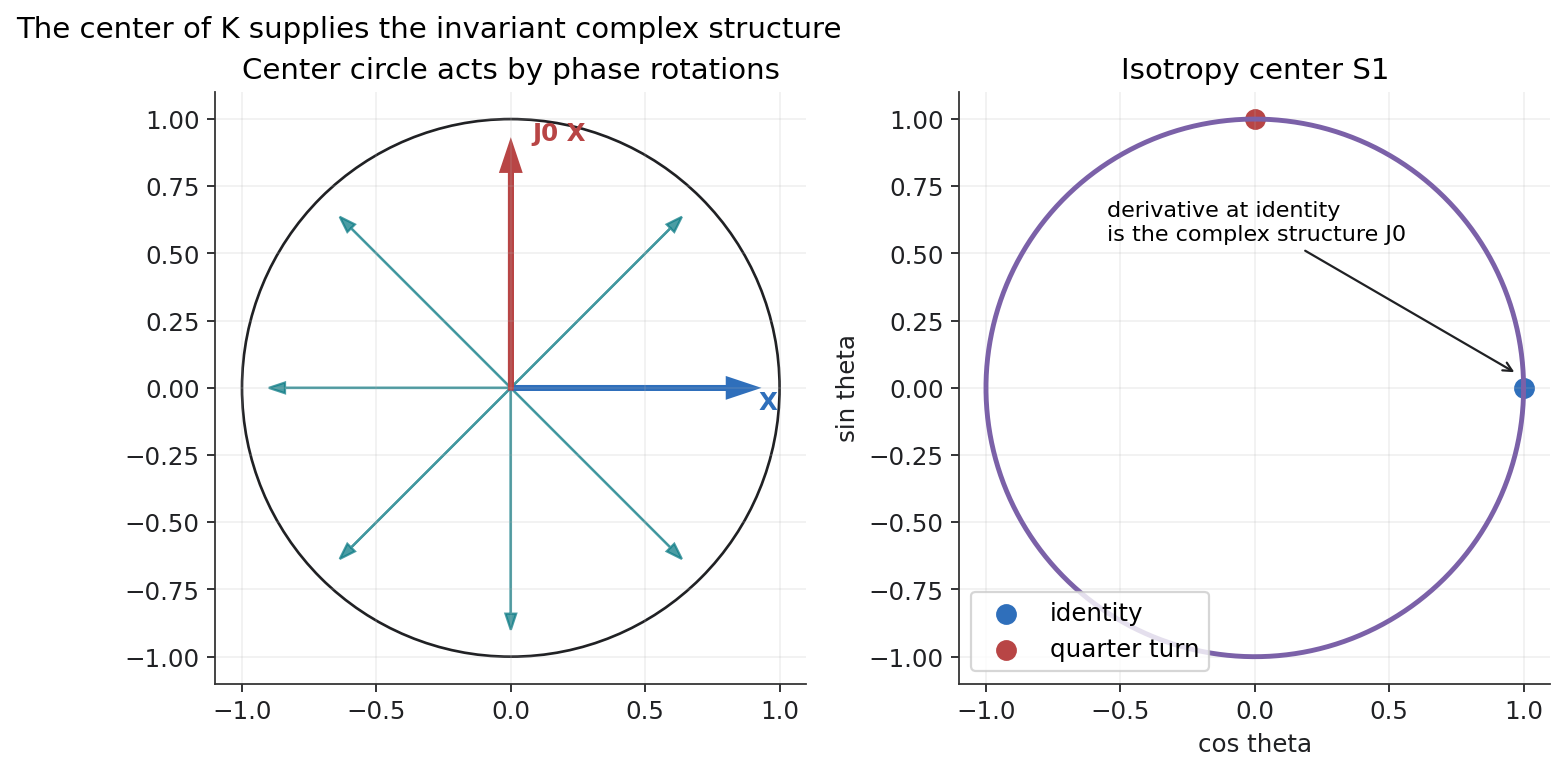

`isotropy-center-complex-structure.json`

In [8]:
theta_sym = sp.symbols("theta", real=True)
J0 = sp.Matrix([[0, -1], [1, 0]])
Rtheta = sp.Matrix([[sp.cos(theta_sym), -sp.sin(theta_sym)], [sp.sin(theta_sym), sp.cos(theta_sym)]])
center_checks = {
    "J0_squared_is_minus_I": sp.simplify(J0 * J0 + sp.eye(2)) == sp.zeros(2),
    "center_commutes_with_J0": sp.simplify(Rtheta * J0 - J0 * Rtheta) == sp.zeros(2),
    "center_preserves_metric": sp.simplify(Rtheta.T * Rtheta - sp.eye(2)) == sp.zeros(2),
    "derivative_at_identity_is_J0": sp.simplify(Rtheta.diff(theta_sym).subs(theta_sym, 0) - J0) == sp.zeros(2),
}

angles = np.linspace(0, 2 * np.pi, 9)[:-1]
base = np.array([1.0, 0.0])
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.8))
ax = axes[0]
ax.set_aspect("equal")
ax.add_patch(Circle((0, 0), 1, fill=False, color=PALETTE["ink"], lw=1.2))
for th in angles:
    vec = np.array([[math.cos(th), -math.sin(th)], [math.sin(th), math.cos(th)]]) @ base
    ax.arrow(0, 0, vec[0] * 0.9, vec[1] * 0.9, head_width=0.04, length_includes_head=True, color=PALETTE["teal"], alpha=0.75)
ax.arrow(0, 0, 0.9, 0, head_width=0.06, length_includes_head=True, color=PALETTE["blue"], lw=2.5)
ax.arrow(0, 0, 0, 0.9, head_width=0.06, length_includes_head=True, color=PALETTE["red"], lw=2.5)
ax.text(0.92, -0.08, "X", color=PALETTE["blue"], weight="bold")
ax.text(0.08, 0.92, "J0 X", color=PALETTE["red"], weight="bold")
ax.set_title("Center circle acts by phase rotations")
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.grid(True, alpha=0.18)

ax = axes[1]
th = np.linspace(0, 2 * np.pi, 200)
ax.plot(np.cos(th), np.sin(th), color=PALETTE["violet"], lw=2.2)
ax.scatter([1], [0], color=PALETTE["blue"], s=70, label="identity")
ax.scatter([0], [1], color=PALETTE["red"], s=70, label="quarter turn")
ax.annotate("derivative at identity\nis the complex structure J0", xy=(0.98, 0.05), xytext=(-0.55, 0.55), arrowprops={"arrowstyle": "->", "color": PALETTE["ink"]}, fontsize=10)
ax.set_aspect("equal")
ax.set_title("Isotropy center S1")
ax.set_xlabel("cos theta")
ax.set_ylabel("sin theta")
ax.legend(loc="lower left")
ax.grid(True, alpha=0.18)
fig.suptitle("The center of K supplies the invariant complex structure", x=0.02, ha="left")

center_path = save_matplotlib(fig, artifact("figures", "isotropy-center-complex-structure.png"))
plt.close(fig)
center_check_path = save_json({k: bool(v) for k, v in center_checks.items()}, artifact("checks", "isotropy-center-complex-structure.json"))

display_artifact(center_path, width=820)
display_artifact(center_check_path)


## Cartan-Harish-Chandra Realization

The final section proves the two-way bridge:

`bounded symmetric domain with Bergman metric -> Hermitian symmetric space of noncompact type`

and

`Hermitian symmetric space of noncompact type -> bounded symmetric domain in p_-`.

The proof constructs a complexified group picture with `p_-`, `K`, and `p_+`, then writes points in a `P_- K P_+` cell. In strongly orthogonal coordinates the noncompact geodesic parameter becomes bounded by `tanh`. That is the numerical signature we can inspect directly.


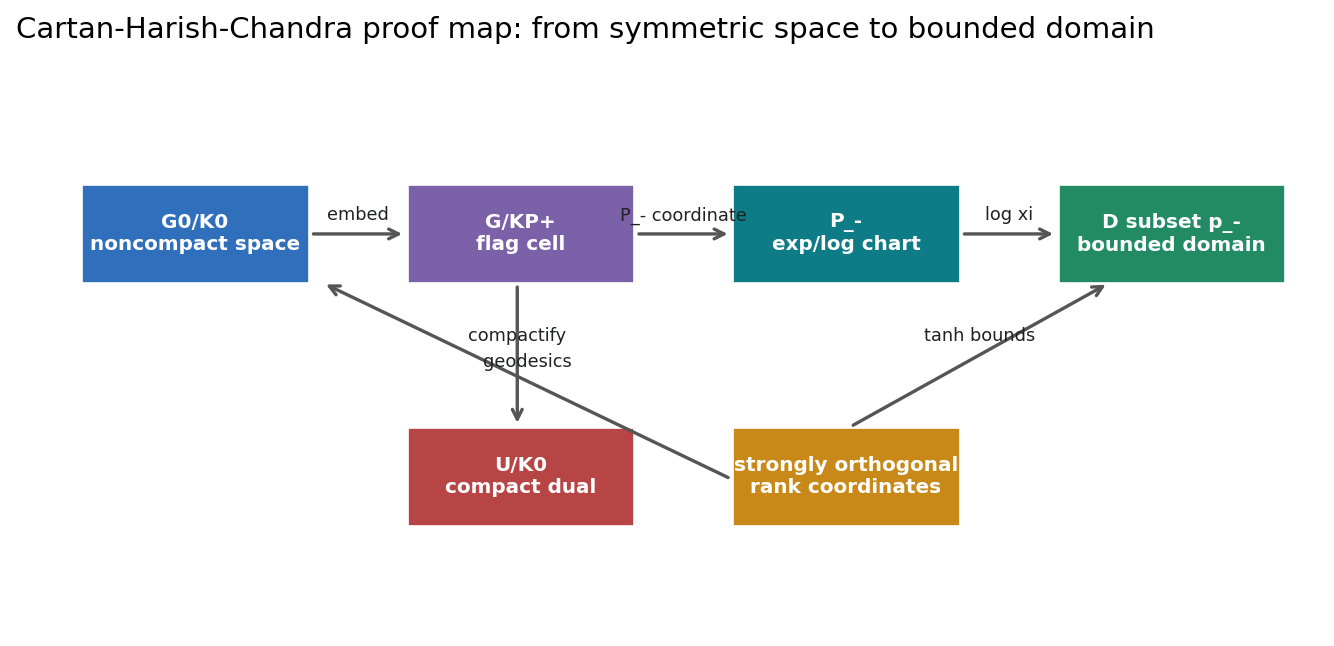

D:\Geometry\.venv\Lib\site-packages\IPython\core\display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


[harish-chandra-tanh-samples.csv](artifacts/chapter-08-hermitian-symmetric-spaces/tables/harish-chandra-tanh-samples.csv)

`harish-chandra-tanh-domain.json`

In [9]:
fig, ax = plt.subplots(figsize=(10.5, 4.7))
ax.axis("off")
ax.set_xlim(0, 10)
ax.set_ylim(0, 5)
diagram_nodes = [
    (0.5, 3.0, "G0/K0\nnoncompact space", PALETTE["blue"]),
    (3.0, 3.0, "G/KP+\nflag cell", PALETTE["violet"]),
    (5.5, 3.0, "P_-\nexp/log chart", PALETTE["teal"]),
    (8.0, 3.0, "D subset p_-\nbounded domain", PALETTE["green"]),
    (3.0, 0.9, "U/K0\ncompact dual", PALETTE["red"]),
    (5.5, 0.9, "strongly orthogonal\nrank coordinates", PALETTE["gold"]),
]
for x0, y0, label, color in diagram_nodes:
    rect = Rectangle((x0, y0), 1.75, 0.85, facecolor=color, edgecolor="white", lw=1.2)
    ax.add_patch(rect)
    ax.text(x0 + 0.875, y0 + 0.425, label, color="white", ha="center", va="center", fontsize=9, weight="bold")
arrows = [
    ((2.25, 3.42), (3.0, 3.42), "embed"),
    ((4.75, 3.42), (5.5, 3.42), "P_- coordinate"),
    ((7.25, 3.42), (8.0, 3.42), "log xi"),
    ((3.85, 3.0), (3.85, 1.75), "compactify"),
    ((6.4, 1.75), (8.4, 3.0), "tanh bounds"),
    ((5.5, 1.3), (2.35, 3.0), "geodesics"),
]
for start, end, label in arrows:
    ax.annotate("", xy=end, xytext=start, arrowprops={"arrowstyle": "->", "lw": 1.5, "color": "#555555"})
    ax.text((start[0] + end[0]) / 2, (start[1] + end[1]) / 2 + 0.12, label, fontsize=8, color=PALETTE["ink"], ha="center")
ax.set_title("Cartan-Harish-Chandra proof map: from symmetric space to bounded domain", loc="left")
factor_path = save_matplotlib(fig, artifact("figures", "harish-chandra-factorization.png"))
plt.close(fig)

t = np.linspace(-3.0, 3.0, 241)
directions = {
    "root 1": (1.0, 0.0, PALETTE["blue"]),
    "root 2": (0.0, 1.0, PALETTE["green"]),
    "diagonal": (1.0, 1.0, PALETTE["gold"]),
    "mixed": (1.0, -0.55, PALETTE["red"]),
}
fig_plotly = go.Figure()
square_x = [-1, 1, 1, -1, -1]
square_y = [-1, -1, 1, 1, -1]
fig_plotly.add_trace(go.Scatter(x=square_x, y=square_y, mode="lines", name="boundary cube", line={"color": "#202124", "width": 2}))
for name, (a1, a2, color) in directions.items():
    xvals = np.tanh(a1 * t)
    yvals = np.tanh(a2 * t)
    fig_plotly.add_trace(go.Scatter(
        x=xvals,
        y=yvals,
        mode="lines",
        name=name,
        line={"color": color, "width": 3},
        hovertemplate=f"{name}<br>x=%{{x:.3f}}<br>y=%{{y:.3f}}<extra></extra>",
    ))
fig_plotly.add_trace(go.Scatter(x=[-1, -1, 1, 1], y=[-1, 1, -1, 1], mode="markers", name="limit vertices", marker={"color": PALETTE["violet"], "size": 10, "symbol": "diamond"}))
fig_plotly.update_layout(
    title="Rank-two tanh coordinates for the bounded realization",
    xaxis_title="coordinate along X_-gamma1",
    yaxis_title="coordinate along X_-gamma2",
    xaxis={"range": [-1.08, 1.08], "zeroline": True},
    yaxis={"range": [-1.08, 1.08], "scaleanchor": "x", "scaleratio": 1, "zeroline": True},
    template="plotly_white",
    width=760,
    height=640,
)
html_path = artifact("html", "harish-chandra-tanh-domain.html")
fig_plotly.write_html(str(html_path), include_plotlyjs="include", full_html=True)

sample_t = np.array([-3, -1, 0, 1, 3], dtype=float)
lab_rows = [
    {"t": float(v), "tanh_t": float(np.tanh(v)), "tanh_2t": float(np.tanh(2 * v)), "boundary_margin_1_minus_abs_tanh_t": float(1 - abs(np.tanh(v)))}
    for v in sample_t
]
tanh_table_path = save_csv(lab_rows, artifact("tables", "harish-chandra-tanh-samples.csv"))
domain_check = {
    "max_abs_tanh_on_sample": float(np.max(np.abs(np.tanh(t)))),
    "all_sample_points_inside_open_square": bool(np.all(np.abs(np.tanh(t)) < 1)),
    "limit_at_plus_infinity": "vertices with coordinates in {0, +/-1}, depending on geodesic octant",
    "rank_two_directions": list(directions),
}
domain_check_path = save_json(domain_check, artifact("checks", "harish-chandra-tanh-domain.json"))

display_artifact(factor_path, width=860)
display_artifact(html_path, width=780, height=660)
display_artifact(tanh_table_path)
display_artifact(domain_check_path)


## Applied Lab: Move In Bounded Coordinates

The slider lab below is intentionally small. It lets you vary two strongly orthogonal geodesic coordinates and watch the bounded `tanh` image. The important point is not the square itself; it is the mechanism: an unbounded noncompact geodesic parameter is converted into a bounded complex coordinate in `p_-`.


In [10]:
try:
    import ipywidgets as widgets
    from IPython.display import display

    t1_slider = widgets.FloatSlider(value=0.75, min=-3.0, max=3.0, step=0.25, description="t1")
    t2_slider = widgets.FloatSlider(value=-0.5, min=-3.0, max=3.0, step=0.25, description="t2")

    def report_point(t1: float, t2: float) -> None:
        z1 = math.tanh(t1)
        z2 = math.tanh(t2)
        margin = min(1 - abs(z1), 1 - abs(z2))
        print(f"bounded p_- coordinate: ({z1:+.4f}, {z2:+.4f}); boundary margin {margin:.4f}")

    out = widgets.interactive_output(report_point, {"t1": t1_slider, "t2": t2_slider})
    display(widgets.HBox([t1_slider, t2_slider]), out)
except Exception as exc:
    print(f"ipywidgets lab skipped: {exc}")


Output()

## Standalone Concept Summary

**Almost complex to complex.** The operator `J` turns each real tangent space into a complex vector space. The torsion tensor `S` checks whether the formal type split comes from honest complex charts. In local complex coordinates, the coordinate vector fields make this obstruction vanish.

**Hermitian to Kahler.** A Hermitian metric is compatible with `J`; a Kahler metric also has `nabla J = 0`. That parallelism is why type decompositions persist under curvature operations. For a Hermitian symmetric space, geodesic symmetries preserve the complex structure, so parallel translation does too, making the Hermitian metric Kahler.

**Ricci and Bergman.** The Bergman kernel of a bounded domain produces a Kahler metric by differentiating `log K(z,z)`. Holomorphic automorphisms transform the kernel by a Jacobian factor, and the extra logarithmic term disappears under `partial partialbar`; this is why holomorphic automorphisms are Bergman isometries.

**Hermitian symmetric spaces.** In the compact and noncompact irreducible cases, the isotropy representation has a central circle. Its infinitesimal action is the complex structure. This is the practical recognition test used before the bounded-domain construction.

**Bounded realization.** For noncompact type, complexifying the group and using the decomposition involving `p_-`, `K`, and `p_+` produces a holomorphic coordinate map into the abelian vector space `p_-`. Strongly orthogonal roots make the boundedness visible: geodesic coordinates are controlled by `tanh`, and limiting geodesics approach cube vertices.


## Takeaways

- The chapter's first half supplies the local language: `J`, torsion/integrability, type decomposition, Kahler metrics, Ricci curvature, and Bergman kernels.
- The symmetric-space half translates Hermitian geometry into Lie data: a central isotropy circle acts as the complex structure.
- Bounded symmetric domains are not merely examples; with the Bergman metric they are exactly the noncompact Hermitian symmetric spaces in the direction proved here.
- The Cartan-Harish-Chandra map is inspectable in rank coordinates: `t -> tanh(t)` is the computational shadow of the bounded realization.


In [11]:
# final_sanity
required_paths = [
    routing_path,
    dependency_path,
    storyboard_path,
    almost_path,
    almost_check_path,
    block_path,
    block_check_path,
    ricci_path,
    ricci_check_path,
    symmetry_path,
    symmetry_check_path,
    center_path,
    center_check_path,
    factor_path,
    html_path,
    tanh_table_path,
    domain_check_path,
]
assert_artifacts(required_paths, min_bytes=80)

with open(ricci_check_path, "r", encoding="utf-8") as handle:
    ricci_loaded = json.load(handle)
assert ricci_loaded["ricci_over_metric"] == "-1"

with open(symmetry_check_path, "r", encoding="utf-8") as handle:
    symmetry_loaded = json.load(handle)
assert symmetry_loaded["max_involution_error"] < 1e-12
assert symmetry_loaded["max_metric_density_residual"] < 1e-12

with open(center_check_path, "r", encoding="utf-8") as handle:
    center_loaded = json.load(handle)
assert all(center_loaded.values())

with open(domain_check_path, "r", encoding="utf-8") as handle:
    domain_loaded = json.load(handle)
assert domain_loaded["all_sample_points_inside_open_square"]

final_sanity = {
    "unit": UNIT_KEY,
    "source_span": "Helgason Chapter VIII, printed pages 352-400; approximate PDF pages 379-427 inspected.",
    "artifact_count": len(required_paths) + 1,
    "required_artifacts": [path.relative_to(ARTIFACT_ROOT).as_posix() for path in required_paths],
    "core_checks": {
        "almost_complex_projection_checks": True,
        "kahler_block_checks": True,
        "disk_ricci_over_metric": ricci_loaded["ricci_over_metric"],
        "disk_symmetry_metric_residual": symmetry_loaded["max_metric_density_residual"],
        "isotropy_center_checks": center_loaded,
        "harish_chandra_domain_inside": domain_loaded["all_sample_points_inside_open_square"],
    },
}
final_sanity_path = save_json(final_sanity, artifact("checks", "final_sanity.json"))
assert_artifacts([final_sanity_path], min_bytes=80)
display_artifact(final_sanity_path)
print(f"final_sanity passed for {UNIT_TITLE} with {final_sanity['artifact_count']} artifacts")


`final_sanity.json`

final_sanity passed for Hermitian Symmetric Spaces with 18 artifacts
